In [1]:
%load_ext watermark


In [2]:
import io
import math

from Bio import Phylo as BioPhylo
from IPython.display import display, HTML
from hstrat import _auxiliary_lib as hstrat_aux
from matplotlib import pyplot as plt
import polars as pl
from slugify import slugify
from teeplot import teeplot as tp

from pylib._disable_ax_clip import disable_ax_clip
from pylib._draw_biophylo_vertical_refactor import _calc_layout, _render_layout
from pylib._seed_global_rngs import seed_global_rngs


Covasim 3.1.6 (2024-01-28) — © 2020-2024 by IDM


In [3]:
%watermark -diwmuv -iv


Last updated: 2025-06-04T03:38:33.222772+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1029-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

Bio       : 1.85
matplotlib: 3.9.2
hstrat    : 1.20.11
teeplot   : 1.4.2
polars    : 1.29.0

Watermark: 2.4.3



In [4]:
teeplot_subdir = "2025-05-30-vanilla-treeviz-refactor"
teeplot_subdir


'2025-05-30-vanilla-treeviz-refactor'

In [5]:
seed_global_rngs(1)


## Get Data


In [6]:
url = "https://osf.io/r8skg/download"
tmp_path = f"/tmp/{teeplot_subdir}.pqt"

print(f"Downloading data from {url}")

pl.scan_parquet(
    url,
    low_memory=True,
    retries=5,
).sink_parquet(tmp_path)
print("done!")


done!


In [7]:
df = pl.scan_parquet(
    tmp_path,
    low_memory=True,
    retries=5,
)
schema = df.collect_schema()


In [8]:
fil = (
    df.filter(
        pl.col("trt_hsurf_bits").eq(0),
    )
    .filter(
        pl.col("replicate_uuid").eq(
            pl.col("replicate_uuid").first().over("trt_name"),
        )
    )
    .select(
        pl.exclude([k for k, v in schema.items() if v == pl.String]),
    )
    .collect()
)


## Plot Data


In [9]:
def do_plot(
    tree: BioPhylo.BaseTree.Tree,
    interp_unit: float,
    polar: bool,
    y_scale: float,
) -> plt.Axes:
    # 1) compute layout
    layout_df = _calc_layout(tree, y_scale=y_scale, interp_unit=interp_unit)
    display(layout_df)

    # 2) render with interpolation
    return _render_layout(
        layout_df,
        do_show=False,
        polar=polar,
        interp_unit=interp_unit,
    )


680


,id,ancestor_id,layout_position,y_position,color,lw
0,0,0,0.000000,3.088060,#808080,0.45
1,1,0,0.000000,3.088060,#808080,0.45
2,2,1,0.016026,3.088060,#808080,0.45
3,3,2,0.035256,3.088060,#808080,0.45
4,4,3,0.044872,3.088060,#808080,0.45
...,...,...,...,...,...,...
718,718,715,0.543269,3.115842,#808080,0.45
719,719,43,0.511218,3.122280,#808080,0.45
720,720,43,0.532051,3.128717,#808080,0.45
721,721,43,0.525641,3.135155,#808080,0.45


/home/runner/work/multilevel-selection-concept/multilevel-selection-concept/binder/pylib/_draw_biophylo_vertical_refactor.py:142: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x_here = float(df.loc[df["id"] == pid, "layout_position"])


teeplots/2025-05-30-vanilla-treeviz-refactor/trt_name=sben2x-gneu+viz=do-plot+ext=.pdf
teeplots/2025-05-30-vanilla-treeviz-refactor/trt_name=sben2x-gneu+viz=do-plot+ext=.png


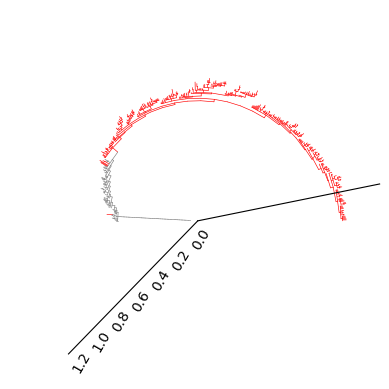

653


,id,ancestor_id,layout_position,y_position,color,lw
0,0,0,0.000000,2.701868,#808080,0.45
1,1,0,0.000000,2.701868,#808080,0.45
2,2,1,0.016181,2.701868,#808080,0.45
3,3,2,0.029126,2.701868,#808080,0.45
4,4,3,0.074434,2.701868,#808080,0.45
...,...,...,...,...,...,...
659,659,658,0.304207,3.113543,#808080,0.45
660,660,658,0.333333,3.120555,#808080,0.45
661,661,11,0.268608,3.127568,#808080,0.45
662,662,11,0.300971,3.134580,#808080,0.45


/home/runner/work/multilevel-selection-concept/multilevel-selection-concept/binder/pylib/_draw_biophylo_vertical_refactor.py:142: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x_here = float(df.loc[df["id"] == pid, "layout_position"])


teeplots/2025-05-30-vanilla-treeviz-refactor/trt_name=sben1-1x-gneu+viz=do-plot+ext=.pdf
teeplots/2025-05-30-vanilla-treeviz-refactor/trt_name=sben1-1x-gneu+viz=do-plot+ext=.png


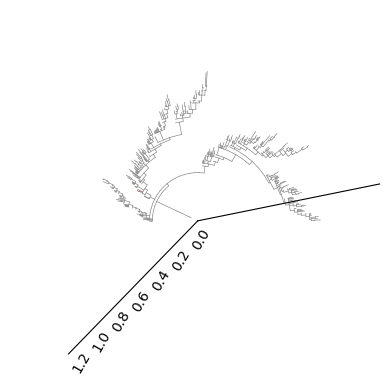

572


,id,ancestor_id,layout_position,y_position,color,lw
0,0,0,0.000000,2.923092,#808080,0.45
1,1,0,0.000000,2.923092,#808080,0.45
2,2,1,0.016241,2.923092,#808080,0.45
3,3,2,0.027842,2.923092,#808080,0.45
4,4,3,0.044084,2.923092,#808080,0.45
...,...,...,...,...,...,...
604,604,37,0.661253,3.110641,#808080,0.45
605,605,37,0.656613,3.118379,#808080,0.45
606,606,37,0.656613,3.126117,#808080,0.45
607,607,37,0.656613,3.133855,#808080,0.45


/home/runner/work/multilevel-selection-concept/multilevel-selection-concept/binder/pylib/_draw_biophylo_vertical_refactor.py:142: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x_here = float(df.loc[df["id"] == pid, "layout_position"])


teeplots/2025-05-30-vanilla-treeviz-refactor/trt_name=sben2x-gdel2x+viz=do-plot+ext=.pdf
teeplots/2025-05-30-vanilla-treeviz-refactor/trt_name=sben2x-gdel2x+viz=do-plot+ext=.png


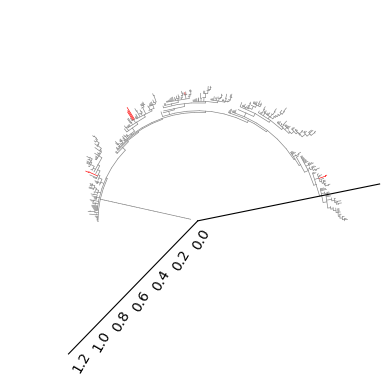

712


,id,ancestor_id,layout_position,y_position,color,lw
0,0,0,0.000000,3.119830,#808080,0.45
1,1,0,0.000000,3.119830,#808080,0.45
2,2,1,0.012727,3.119830,#808080,0.45
3,3,2,0.027273,3.119830,#808080,0.45
4,4,3,0.040000,3.119830,#808080,0.45
...,...,...,...,...,...,...
729,729,23,0.380000,3.116709,#808080,0.45
730,730,23,0.387273,3.122930,#808080,0.45
731,731,22,0.365455,3.129151,#808080,0.45
732,732,22,0.385455,3.135372,#808080,0.45


/home/runner/work/multilevel-selection-concept/multilevel-selection-concept/binder/pylib/_draw_biophylo_vertical_refactor.py:142: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x_here = float(df.loc[df["id"] == pid, "layout_position"])


teeplots/2025-05-30-vanilla-treeviz-refactor/trt_name=sben1-3x-gneu+viz=do-plot+ext=.pdf
teeplots/2025-05-30-vanilla-treeviz-refactor/trt_name=sben1-3x-gneu+viz=do-plot+ext=.png


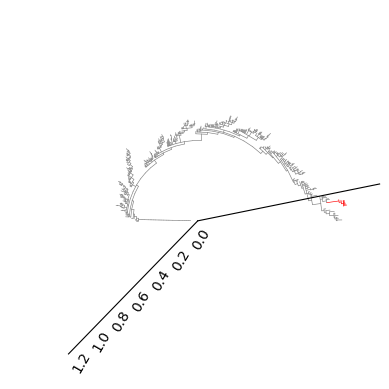

670


,id,ancestor_id,layout_position,y_position,color,lw
0,0,0,0.000000,3.029890,#808080,0.45
1,1,0,0.000000,3.029890,#808080,0.45
2,2,1,0.010786,3.029890,#808080,0.45
3,3,2,0.018490,3.029890,#808080,0.45
4,4,3,0.024653,3.029890,#808080,0.45
...,...,...,...,...,...,...
709,709,701,0.580894,3.115413,#808080,0.45
710,710,701,0.596302,3.121958,#808080,0.45
711,711,701,0.588598,3.128503,#808080,0.45
712,712,44,0.560863,3.135048,#808080,0.45


/home/runner/work/multilevel-selection-concept/multilevel-selection-concept/binder/pylib/_draw_biophylo_vertical_refactor.py:142: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x_here = float(df.loc[df["id"] == pid, "layout_position"])


teeplots/2025-05-30-vanilla-treeviz-refactor/trt_name=sben1-1x-gdel1-1x+viz=do-plot+ext=.pdf
teeplots/2025-05-30-vanilla-treeviz-refactor/trt_name=sben1-1x-gdel1-1x+viz=do-plot+ext=.png


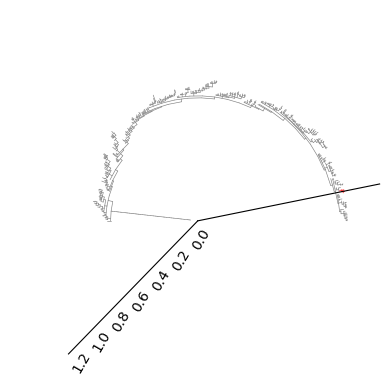

591


,id,ancestor_id,layout_position,y_position,color,lw
0,0,0,0.000000,3.051432,#808080,0.45
1,1,0,0.000000,3.051432,#808080,0.45
2,2,1,0.010549,3.051432,#808080,0.45
3,3,2,0.021097,3.051432,#808080,0.45
4,4,3,0.044304,3.051432,#808080,0.45
...,...,...,...,...,...,...
603,603,17,0.381857,3.111312,#808080,0.45
604,604,17,0.379747,3.118882,#808080,0.45
605,605,17,0.375527,3.126452,#808080,0.45
606,606,17,0.375527,3.134023,#808080,0.45


/home/runner/work/multilevel-selection-concept/multilevel-selection-concept/binder/pylib/_draw_biophylo_vertical_refactor.py:142: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x_here = float(df.loc[df["id"] == pid, "layout_position"])


teeplots/2025-05-30-vanilla-treeviz-refactor/trt_name=sben1-3x-gdel1-3x+viz=do-plot+ext=.pdf
teeplots/2025-05-30-vanilla-treeviz-refactor/trt_name=sben1-3x-gdel1-3x+viz=do-plot+ext=.png


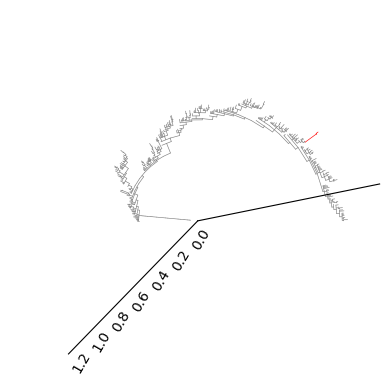

590


,id,ancestor_id,layout_position,y_position,color,lw
0,0,0,0.000000,3.014523,#808080,0.45
1,1,0,0.000000,3.014523,#808080,0.45
2,2,1,0.011173,3.014523,#808080,0.45
3,3,2,0.033520,3.014523,#808080,0.45
4,4,3,0.047486,3.014523,#808080,0.45
...,...,...,...,...,...,...
602,602,17,0.329609,3.111385,#808080,0.45
603,603,17,0.329609,3.118937,#808080,0.45
604,604,17,0.310056,3.126489,#808080,0.45
605,605,17,0.310056,3.134041,#808080,0.45


/home/runner/work/multilevel-selection-concept/multilevel-selection-concept/binder/pylib/_draw_biophylo_vertical_refactor.py:142: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x_here = float(df.loc[df["id"] == pid, "layout_position"])


teeplots/2025-05-30-vanilla-treeviz-refactor/trt_name=sneu-gneu+viz=do-plot+ext=.pdf
teeplots/2025-05-30-vanilla-treeviz-refactor/trt_name=sneu-gneu+viz=do-plot+ext=.png


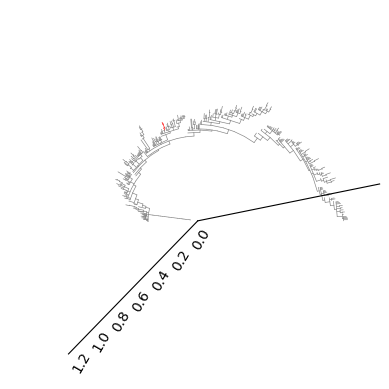

In [10]:
for (trt_name,), group in fil.group_by("trt_name"):
    display(HTML(f"<h1>{trt_name}</h1>"))

    phylo_df = group.to_pandas()

    phylo_df = hstrat_aux.alifestd_mark_num_descendants_asexual(phylo_df)
    phylo_df = hstrat_aux.alifestd_mark_clade_duration_asexual(phylo_df)
    phylo_df[
        "calc_clade_trait_count_asexual"
    ] = hstrat_aux.alifestd_calc_clade_trait_count_asexual(
        phylo_df, trait_mask=phylo_df["is_focal_defmut"].values
    )

    mask = (
        (phylo_df["origin_time"] > 50)
        & (phylo_df["num_descendants"] >= 500)
        & (phylo_df["num_descendants"] <= 750)
        & (phylo_df["calc_clade_trait_count_asexual"] > 0)
    )
    sample_idx = phylo_df.loc[mask, "id"].sample(n=1, random_state=1).item()
    sample_mask = phylo_df["id"] == sample_idx

    phylo_df = hstrat_aux.alifestd_mask_descendants_asexual(
        phylo_df,
        ancestor_mask=phylo_df["is_focal_defmut"],
    ).rename(
        columns={
            "alifestd_mask_descendants_asexual": "focal_defmut_descendant",
        },
    )

    phylo_df = hstrat_aux.alifestd_mask_descendants_asexual(
        phylo_df,
        ancestor_mask=sample_mask,
    )

    phylo_df["extant"] = phylo_df["alifestd_mask_descendants_asexual"]
    print(phylo_df["extant"].sum())
    phylo_df = hstrat_aux.alifestd_prune_extinct_lineages_asexual(phylo_df)

    sample_ot_min = phylo_df.loc[
        phylo_df["extant"].values, "origin_time"
    ].min()
    sample_ot_max = phylo_df.loc[
        phylo_df["extant"].values, "origin_time"
    ].max()

    newick = hstrat_aux.alifestd_as_newick_asexual(
        phylo_df,
        taxon_label="focal_defmut_descendant",
    )

    tree = BioPhylo.read(io.StringIO(newick), "newick")
    tree.ladderize(reverse=True)

    for clade in tree.find_clades():
        clade.color = "red" if clade.name == "True" else "gray"
        clade.width = 0.3

    with tp.teed(
        do_plot,
        tree,
        interp_unit=0.1,
        polar=True,
        y_scale=math.pi,
        teeplot_subdir=teeplot_subdir,
        teeplot_outattrs={
            "trt_name": slugify(trt_name),
        },
    ) as ax:
        # ax.set_xlim(0, math.pi)
        # ax.set_ylim(max(sample_ot_min - 50, -20), sample_ot_max + 20)
        ax.grid(False)
        ax.get_xaxis().set_visible(False)
        ax.get_xaxis().set_visible(False)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.spines["polar"].set_visible(False)
        ax.spines["start"].set_visible(False)
        ax.spines["end"].set_visible(False)
        ax.spines["inner"].set_visible(False)
        ax.tick_params(axis="x", labelrotation=60)
        ax.tick_params(axis="y", labelrotation=60)

        disable_ax_clip(ax)

    plt.show()
    plt.close("all")  # release resources
